<a href="https://colab.research.google.com/github/SyedMZaim/AMALI-DKB3263/blob/main/SYED_PB_AMALI_DKB3263.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SYED PB AMALI DKB3263**

# 1. Import libraries

In [1]:
# CELL 1: Import Libraries

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Check PyTorch version
print("PyTorch Version:", torch.__version__)

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

PyTorch Version: 2.11.0+cpu
Device: cpu


# 2. Load MNIST

In [2]:
# CELL 2: Load MNIST Dataset

# Convert images into tensors and normalize pixel values
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Download and load training dataset
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# Download and load testing dataset
test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 133MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 53.5MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 81.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.9MB/s]


Training samples: 60000
Testing samples: 10000


# 3. Preprocessing

In [3]:
# CELL 3: Create DataLoaders

# Batch size
batch_size = 64

# Create DataLoader for training and testing
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

# Check one batch
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: torch.Size([64, 1, 28, 28])
Label batch shape: torch.Size([64])


# 4. Bina ANN

In [4]:
# CELL 4: Build Artificial Neural Network (ANN)

class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        # Input layer: 28 x 28 = 784 pixels
        self.input_layer = nn.Linear(28 * 28, 128)

        # Hidden layer
        self.hidden_layer = nn.Linear(128, 64)

        # Output layer: 10 classes (digits 0-9)
        self.output_layer = nn.Linear(64, 10)

        # Activation function
        self.relu = nn.ReLU()

    def forward(self, x):
        # Flatten image from 28x28 into 784
        x = x.view(x.size(0), -1)

        # Input -> Hidden
        x = self.input_layer(x)
        x = self.relu(x)

        # Hidden -> Hidden
        x = self.hidden_layer(x)
        x = self.relu(x)

        # Hidden -> Output
        x = self.output_layer(x)

        return x


# Create model
model = ANN().to(device)

# Display model structure
print(model)

ANN(
  (input_layer): Linear(in_features=784, out_features=128, bias=True)
  (hidden_layer): Linear(in_features=128, out_features=64, bias=True)
  (output_layer): Linear(in_features=64, out_features=10, bias=True)
  (relu): ReLU()
)


# 5. Loss + Optimizer

In [5]:
# CELL 5: Define Loss Function and Optimizer

# CrossEntropyLoss is used for multi-class classification
criterion = nn.CrossEntropyLoss()

# Learning rate
learning_rate = 0.001

# Adam optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=learning_rate
)

print("Loss Function:", criterion)
print("Optimizer: Adam")
print("Learning Rate:", learning_rate)

Loss Function: CrossEntropyLoss()
Optimizer: Adam
Learning Rate: 0.001


# 6. Training

In [6]:
# CELL 6: Training the ANN Model

num_epochs = 10

# Store loss for every epoch
train_losses = []

for epoch in range(num_epochs):

    model.train()
    running_loss = 0.0

    for images, labels in train_loader:

        # Move data to device
        images = images.to(device)
        labels = labels.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item()

    # Calculate average loss
    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}], "
        f"Loss: {epoch_loss:.4f}"
    )

print("Training completed!")

Epoch [1/10], Loss: 0.2665
Epoch [2/10], Loss: 0.1069
Epoch [3/10], Loss: 0.0762
Epoch [4/10], Loss: 0.0590
Epoch [5/10], Loss: 0.0475
Epoch [6/10], Loss: 0.0399
Epoch [7/10], Loss: 0.0328
Epoch [8/10], Loss: 0.0282
Epoch [9/10], Loss: 0.0256
Epoch [10/10], Loss: 0.0247
Training completed!


# 7. Testing Accuracy

In [12]:
# CELL 7: Test the ANN Model

model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)

        # Get predicted class
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

# Calculate accuracy
accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 97.48%


# 8. Plot Loss

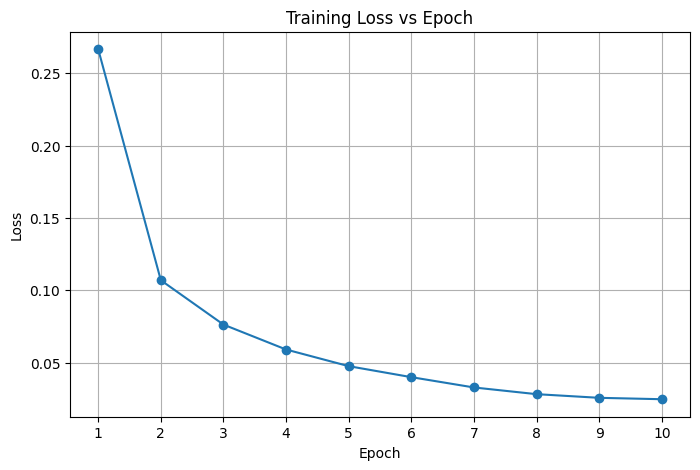

In [8]:
# CELL 8: Plot Loss vs Epoch

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, num_epochs + 1),
    train_losses,
    marker='o'
)

plt.title("Training Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(range(1, num_epochs + 1))
plt.grid(True)

plt.show()

# 9. Hyperparameter Tuning

In [9]:
# CELL 9: Hyperparameter Tuning
# Change learning rate from 0.001 to 0.0005

# Original result
original_accuracy = accuracy

# Create a new model for tuning
tuned_model = ANN().to(device)

# New learning rate
tuned_learning_rate = 0.0005

# New optimizer
tuned_optimizer = optim.Adam(
    tuned_model.parameters(),
    lr=tuned_learning_rate
)

# Train tuned model
tuned_epochs = 10

for epoch in range(tuned_epochs):

    tuned_model.train()
    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Clear gradients
        tuned_optimizer.zero_grad()

        # Forward pass
        outputs = tuned_model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()

        # Update weights
        tuned_optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    print(
        f"Tuned Epoch [{epoch + 1}/{tuned_epochs}], "
        f"Loss: {epoch_loss:.4f}"
    )

# Test tuned model
tuned_model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = tuned_model(images)

        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

tuned_accuracy = 100 * correct / total

print("\n--- Hyperparameter Tuning Result ---")
print(f"Original Learning Rate: {learning_rate}")
print(f"Original Accuracy: {original_accuracy:.2f}%")
print(f"Tuned Learning Rate: {tuned_learning_rate}")
print(f"Tuned Accuracy: {tuned_accuracy:.2f}%")

Tuned Epoch [1/10], Loss: 0.3287
Tuned Epoch [2/10], Loss: 0.1367
Tuned Epoch [3/10], Loss: 0.0968
Tuned Epoch [4/10], Loss: 0.0759
Tuned Epoch [5/10], Loss: 0.0587
Tuned Epoch [6/10], Loss: 0.0477
Tuned Epoch [7/10], Loss: 0.0396
Tuned Epoch [8/10], Loss: 0.0310
Tuned Epoch [9/10], Loss: 0.0268
Tuned Epoch [10/10], Loss: 0.0232

--- Hyperparameter Tuning Result ---
Original Learning Rate: 0.001
Original Accuracy: 97.48%
Tuned Learning Rate: 0.0005
Tuned Accuracy: 97.64%


# 10. Perbandingan keputusan

In [10]:
# CELL 10: Final Comparison

print("=" * 45)
print("ANN MNIST - FINAL RESULTS")
print("=" * 45)

print(f"Original Learning Rate : {learning_rate}")
print(f"Original Accuracy      : {original_accuracy:.2f}%")

print("-" * 45)

print(f"Tuned Learning Rate    : {tuned_learning_rate}")
print(f"Tuned Accuracy         : {tuned_accuracy:.2f}%")

print("-" * 45)

improvement = tuned_accuracy - original_accuracy

print(f"Accuracy Improvement   : {improvement:+.2f}%")

print("=" * 45)

ANN MNIST - FINAL RESULTS
Original Learning Rate : 0.001
Original Accuracy      : 97.48%
---------------------------------------------
Tuned Learning Rate    : 0.0005
Tuned Accuracy         : 97.64%
---------------------------------------------
Accuracy Improvement   : +0.16%
